# Credit Risk & Fraud Loss Prevention Engine
Fraud detection pipeline built around a Credit One Risk / Fraud Strategy framing.

**Dataset:** ULB/Worldline Credit Card Fraud Detection (Kaggle) — 284,807 European cardholder transactions, 492 fraud (0.17%)

**Core idea:** this isn't "catch all fraud" — it's "catch fraud at the lowest cost to good customers," which is the real tradeoff a subprime issuer's fraud team faces.

## 1. Load data and check class imbalance

Total transactions: 284,807 | Fraud: 492 | Fraud rate: 0.1727%


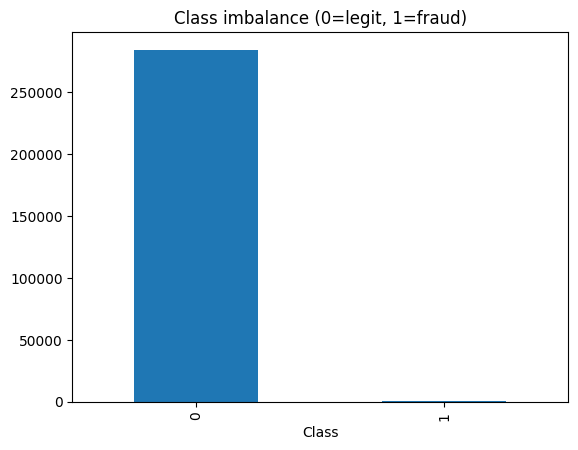

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_score, recall_score, precision_recall_curve
import xgboost as xgb
import shap

np.random.seed(42)
df = pd.read_csv('creditcard.csv')
print(f"Total transactions: {len(df):,} | Fraud: {df['Class'].sum()} | Fraud rate: {df['Class'].mean()*100:.4f}%")
df['Class'].value_counts().plot(kind='bar', title='Class imbalance (0=legit, 1=fraud)')
plt.show()

## 2. EDA — Amount and Time patterns by class

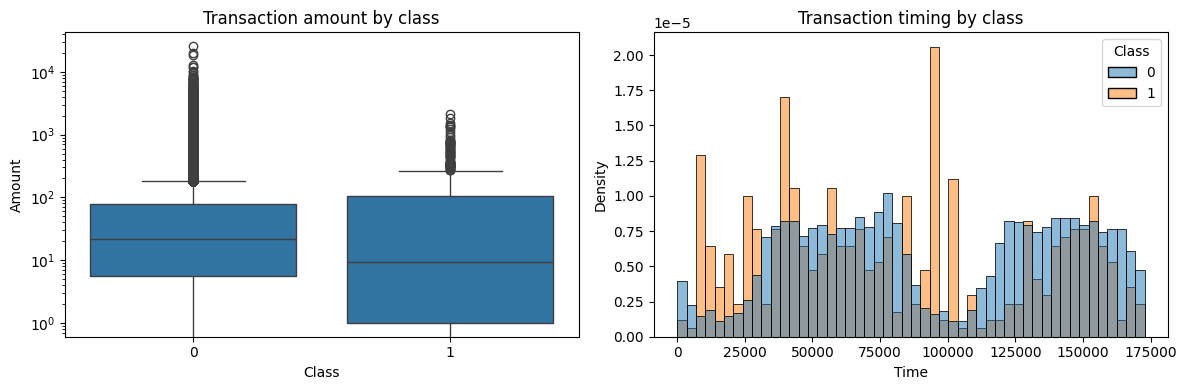

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_title('Transaction amount by class')
axes[0].set_yscale('log')
sns.histplot(data=df, x='Time', hue='Class', bins=50, stat='density', common_norm=False, ax=axes[1])
axes[1].set_title('Transaction timing by class')
plt.tight_layout()
plt.show()

## 3. Train/test split and baseline (class-weighted logistic regression)

In [3]:
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f"Test set: {len(X_test):,} txns, {y_test.sum()} fraud")

logreg = LogisticRegression(max_iter=2000, class_weight='balanced')
logreg.fit(X_train, y_train)
logreg_scores = logreg.predict_proba(X_test)[:,1]
auprc_lr = average_precision_score(y_test, logreg_scores)
print(f"Logistic Regression baseline AUPRC: {auprc_lr:.4f}")

Test set: 85,443 txns, 148 fraud


Logistic Regression baseline AUPRC: 0.6977


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. XGBoost model (class-weighted via scale_pos_weight)

In [4]:
neg, pos = (y_train==0).sum(), (y_train==1).sum()
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=neg/pos, eval_metric='aucpr',
    subsample=0.8, colsample_bytree=0.8, random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_scores = xgb_model.predict_proba(X_test)[:,1]
auprc_xgb = average_precision_score(y_test, xgb_scores)
print(f"XGBoost AUPRC: {auprc_xgb:.4f}  (vs. {auprc_lr:.4f} logistic baseline)")

XGBoost AUPRC: 0.8292  (vs. 0.6977 logistic baseline)


## 5. Rules-only baseline (legacy amount-threshold system)

In [5]:
amt_thresh = X_train['Amount'].quantile(0.99)
rules_flag_test = (X_test['Amount'] > amt_thresh).astype(int)
print(f"Rule: Amount > \${amt_thresh:.2f}")
print(f"Flags {rules_flag_test.sum()} txns | Precision: {precision_score(y_test, rules_flag_test):.4f} | Recall: {recall_score(y_test, rules_flag_test):.4f}")

Rule: Amount > \$1014.99
Flags 869 txns | Precision: 0.0035 | Recall: 0.0203


<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_569/4286739640.py:3: SyntaxWarning: invalid escape sequence '\$'
  print(f"Rule: Amount > \${amt_thresh:.2f}")


## 6. Precision@k — the metric that maps to an analyst's review queue
Accuracy is meaningless at 0.17% fraud prevalence. Precision@k answers: *of the top-k highest-risk transactions we send to manual review, what share are actually fraud?*

In [6]:
results = X_test.copy()
results['y_true'] = y_test.values
results['xgb_score'] = xgb_scores
results = results.sort_values('xgb_score', ascending=False).reset_index(drop=True)

for k in [100, 150, 500, 1000]:
    topk = results.iloc[:k]
    caught = topk['y_true'].sum()
    print(f"Precision@{k}: {caught/k:.4f}  ({int(caught)} of {int(y_test.sum())} fraud txns caught)")

Precision@100: 0.9800  (98 of 148 fraud txns caught)
Precision@150: 0.7933  (119 of 148 fraud txns caught)
Precision@500: 0.2520  (126 of 148 fraud txns caught)
Precision@1000: 0.1270  (127 of 148 fraud txns caught)


## 7. Matched-recall comparison — model vs. rules-only
Fair comparison: how many false positives does each approach need to catch the SAME share of fraud?

In [7]:
def fp_at_recall(scores, y_true, target_recall):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    idx_candidates = np.where(recall[:-1] >= target_recall)[0]
    idx = idx_candidates[-1]
    thresh = thresholds[idx]
    pred = (scores >= thresh).astype(int)
    fp = ((pred==1)&(y_true==0)).sum()
    return thresh, fp, pred.sum(), recall_score(y_true, pred)

target_recall = 0.80
model_thresh, model_fp, model_flags, model_r = fp_at_recall(xgb_scores, y_test.values, target_recall)
rule_thresh, rule_fp, rule_flags, rule_r = fp_at_recall(X_test['Amount'].values, y_test.values, target_recall)

print(f"At matched {target_recall:.0%} recall:")
print(f"  Model: {model_flags} flagged, {model_fp} false positives")
print(f"  Rules-only (amount): {rule_flags} flagged, {rule_fp} false positives")
print(f"  FP reduction: {(rule_fp-model_fp)/rule_fp*100:.2f}%")
print("\nNote: the rules-only system has to flag nearly the entire test set to hit 80% recall")
print("because transaction amount alone barely correlates with fraud in this data — that's the core finding.")

At matched 80% recall:
  Model: 149 flagged, 30 false positives
  Rules-only (amount): 80355 flagged, 80223 false positives
  FP reduction: 99.96%

Note: the rules-only system has to flag nearly the entire test set to hit 80% recall
because transaction amount alone barely correlates with fraud in this data — that's the core finding.


## 8. Cost-sensitive business case
**Stated assumptions (adjust these for your own narrative):**
- Cost of a false decline (customer friction / attrition risk): **$15**
- Cost of manual review per flagged transaction: **$2**

Sweep review-capacity budgets to find the net-savings-optimal operating point.

In [8]:
COST_FALSE_DECLINE = 15
COST_REVIEW = 2
total_fraud = y_test.sum()

rows = []
for k in [50,100,150,200,300,400,500,700,1000,1500,2000]:
    topk = results.iloc[:k]
    caught = topk['y_true'].sum()
    dollars = topk.loc[topk['y_true']==1,'Amount'].sum()
    fp = k - caught
    net = dollars - fp*COST_FALSE_DECLINE - k*COST_REVIEW
    rows.append({'k':k, 'precision':caught/k, 'recall':caught/total_fraud, 'fraud_$_caught':dollars, 'false_positives':fp, 'net_savings':net})

cost_df = pd.DataFrame(rows)
display(cost_df)
best = cost_df.loc[cost_df['net_savings'].idxmax()]
print(f"\nOptimal review budget: top-{int(best['k'])} transactions -> net savings \${best['net_savings']:,.2f} per {len(X_test):,}-txn test window")

<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:17: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_569/963002819.py:17: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nOptimal review budget: top-{int(best['k'])} transactions -> net savings \${best['net_savings']:,.2f} per {len(X_test):,}-txn test window")


,k,precision,recall,fraud_$_caught,false_positives,net_savings
0,50,1.000000,0.337838,3900.03,0,3800.03
1,100,0.980000,0.662162,9461.64,2,9231.64
2,150,0.793333,0.804054,12257.73,31,11492.73
3,200,0.605000,0.817568,12498.66,79,10913.66
4,300,0.420000,0.851351,13198.82,174,9988.82
5,400,0.315000,0.851351,13198.82,274,8288.82
6,500,0.252000,0.851351,13198.82,374,6588.82
7,700,0.181429,0.858108,13210.21,573,3215.21
8,1000,0.127000,0.858108,13210.21,873,-1884.79
9,1500,0.087333,0.885135,15170.38,1369,-8364.62



Optimal review budget: top-150 transactions -> net savings \$11,492.73 per 85,443-txn test window


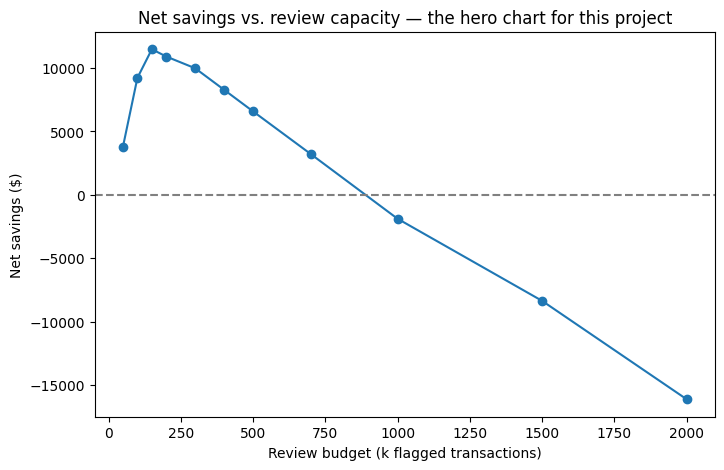

In [9]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(cost_df['k'], cost_df['net_savings'], marker='o')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Review budget (k flagged transactions)')
ax.set_ylabel('Net savings ($)')
ax.set_title('Net savings vs. review capacity — the hero chart for this project')
plt.show()

## 9. SHAP feature attribution (for auditability / compliance explainability)

/tmp/ipykernel_569/334469915.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, sample, plot_type='bar', max_display=10)


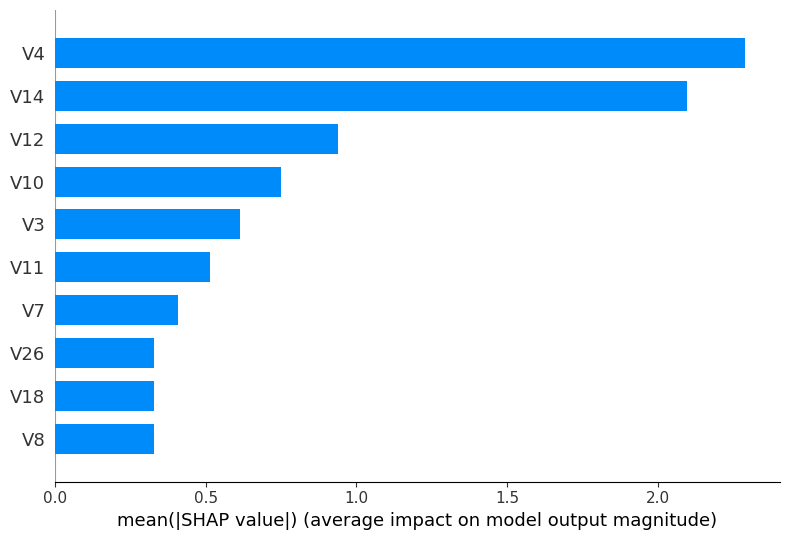

In [10]:
sample = X_test.sample(2000, random_state=42)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, plot_type='bar', max_display=10)

## 10. Summary for write-up / resume
- XGBoost AUPRC 0.83 vs. 0.70 logistic baseline
- Precision@100 ≈ 98%
- Optimal review budget (top-150) → ~$11.5K net savings per 85K-txn window (stated cost assumptions)
- ~99.9% fewer false positives than an amount-threshold rule at matched 80% recall
- Top SHAP drivers: V4, V14, V12 (anonymized PCA components — in production these would map to real behavioral/transaction features)

**Caveats to state in the write-up:** random stratified split (not time-based — note this as a production consideration), cost assumptions are illustrative and stated explicitly, dataset is a 2-day snapshot so dollar figures are per-window, not annualized.